In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import colormaps
cmap = colormaps['viridis']

final = r"C:\Users\Utilisateur\Desktop\IRONHACK_DA\COURSES\week-4\first_project\data\clean\final_dataset.csv"
df = pd.read_csv(final)
df = df.drop(['Unnamed: 0','code'], axis=1)
df.drop_duplicates(inplace=True)

In [2]:
df

,year,country,Christianity,Judaism,Islam,Buddhism,Hindu,Shinto,Confus_Tao,gdp,un_region,hdi,conflict_present
0,1990,United States,214425162,5508504,2294757,1575481,323352,59724,106818,5.963144e+12,Northern America,0.875,0.0
1,1995,United States,215593975,5259463,2425377,1608346,574269,57972,62455,7.639749e+12,Northern America,0.000,0.0
2,2000,United States,219818305,5010424,2555997,2449569,825186,56220,18093,1.025095e+13,Northern America,0.894,0.0
3,2005,United States,226464805,5536622,2685374,3682694,1311442,60560,90593,1.303920e+13,Northern America,0.000,0.0
4,2010,United States,233111307,5942248,2814750,3410236,1797698,156375,95752,1.504896e+13,Northern America,0.916,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
917,1990,Samoa,159500,0,37,15,0,0,0,1.257663e+08,Oceania,0.672,0.0
918,1995,Samoa,161677,0,43,16,0,0,0,2.248657e+08,Oceania,0.000,0.0
919,2000,Samoa,174600,0,50,18,0,0,0,2.588561e+08,Oceania,0.672,0.0
920,2005,Samoa,177510,0,58,18,0,0,0,4.768018e+08,Oceania,0.000,0.0


In [3]:
# real long format
long_df = df.melt(id_vars=['year','country','gdp','un_region','hdi','conflict_present'], var_name ='religion', value_name = 'relig_pop')

In [14]:
# export
#long_df.to_csv(r"C:\Users\Utilisateur\Desktop\IRONHACK_DA\COURSES\week-4\first_project\data\raw\long_df.csv")

In [4]:
df = long_df.copy()

In [5]:
# Replace the countries names accordingly
df["un_region"] = df["un_region"].replace("Latin America and the Caribbean", "Southern America")

In [6]:
df.un_region.unique()

<StringArray>
['Northern America', 'Southern America', 'Europe', 'Asia', 'Africa',
 'Oceania']
Length: 6, dtype: str

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_21844\2181444066.py:12: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.lineplot(


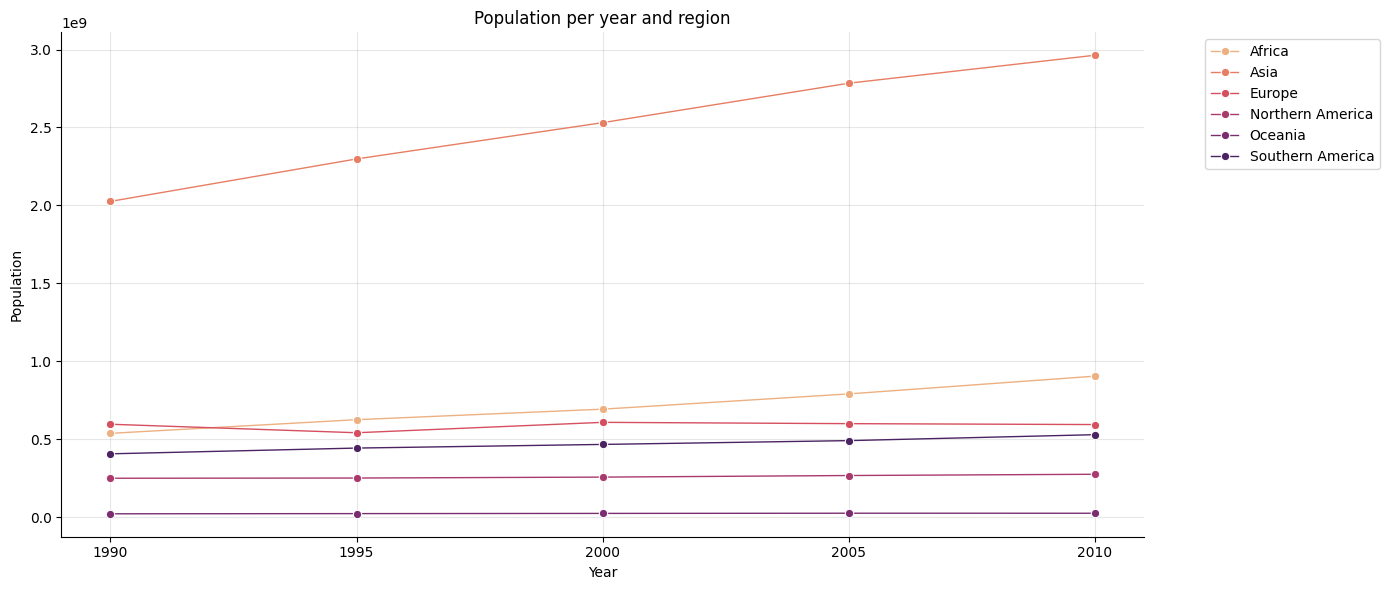

In [7]:
# Total religious population per year and per region

pop_region_year = (df.groupby(["year", "un_region"], as_index=False)["relig_pop"].sum())

# regions unique
n = pop_region_year["un_region"].nunique()

# color for each region (from continuous to non continuous data)
colors = colormaps['flare'](np.linspace(0, 1, n))

plt.figure(figsize=(14,6))
sns.lineplot(
    data=pop_region_year,
    x="year",
    y="relig_pop",
    hue="un_region",
    marker="o",
    linewidth=1,
    markersize=6,
    palette=colors
)

# plot customize
plt.title("Population per year and region")
plt.xlabel("Year")
plt.ylabel("Population")
plt.grid(alpha=0.3)
plt.xticks(sorted(pop_region_year["year"].unique()))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize = 10)
plt.tight_layout()
sns.despine()
plt.savefig("FigA.1.PopRegYear_linechart.png", dpi=300)

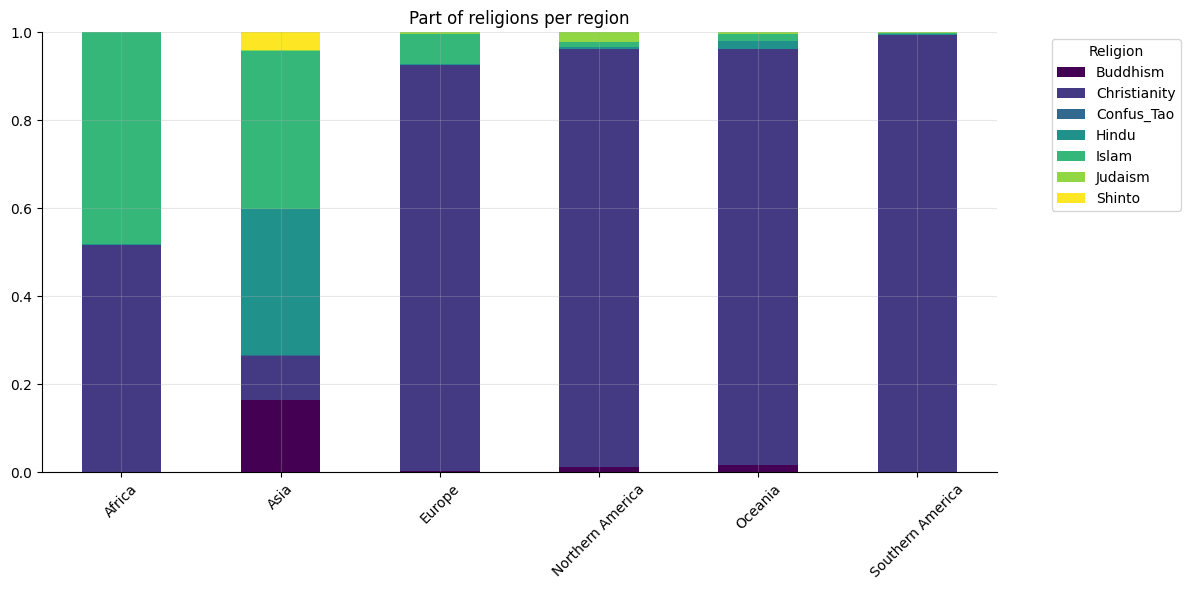

In [8]:
# Distribution of religions among regions 
from matplotlib import colormaps
cmap = colormaps['viridis']

# mean per region
mean_relig = (df.groupby(["un_region", "religion"], as_index=False)["relig_pop"].mean())

# pivot table per region per religion (unstack)
pivot_relig = mean_relig.pivot(
    index="un_region",
    columns="religion",
    values="relig_pop"
).fillna(0)

# percentage of each religion by region  (.div => division, sum(axis=1) means total of the row, 
pivot_pct = pivot_relig.div(pivot_relig.sum(axis=1), axis=0)

cmap = colormaps['viridis']
colors = cmap(np.linspace(0, 1, pivot_pct.shape[1]))



pivot_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    color=colors
)

sns.despine()
plt.title("Part of religions per region")
plt.xlabel("")
plt.ylabel("")
plt.grid(alpha = 0.3)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title="Religion", bbox_to_anchor=(1.05,1), fontsize=10)
plt.tight_layout()
plt.savefig("FigA.2.ReligionPartPerRegion.png", dpi=300)
plt.show() #to put AFTER savefig because it erases once showed

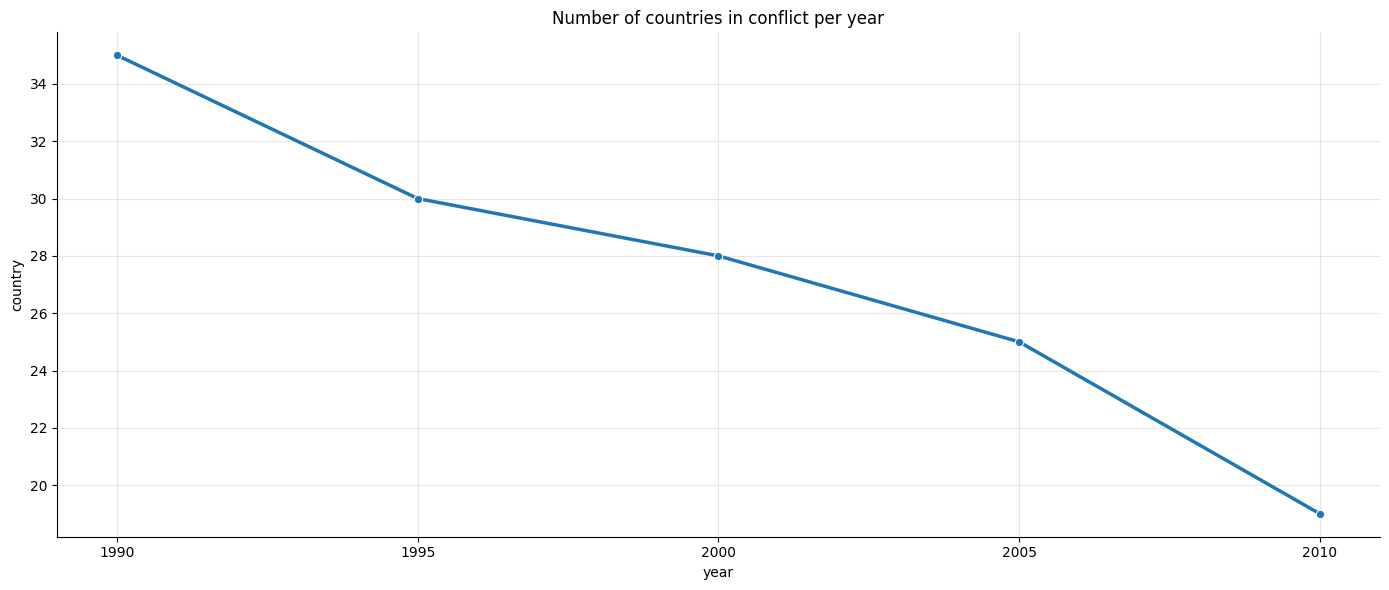

In [9]:
# Countries in conflict per year 

conflict_countries = df[df["conflict_present"] == 1]
conflict_countries = conflict_countries.groupby(["year"], as_index=False)["country"].nunique()

plt.figure(figsize=(14,6))
sns.lineplot(
    data=conflict_countries,
    x="year",
    y="country",
    marker="o",
    linewidth=2.5
)


# plot customize
sns.despine()
plt.title("Number of countries in conflict per year")
#plt.xlabel("Year", fontsize = 10)
#plt.ylabel("Population", fontsize = 10)
plt.grid(alpha=0.3)
plt.xticks(sorted(conflict_countries["year"].unique()))
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize = 10)
plt.tight_layout()
plt.savefig("FigA.3.NbCountriesConflict_Year_linechart.png", dpi=300)
plt.show()

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_21844\261299210.py:13: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.lineplot(


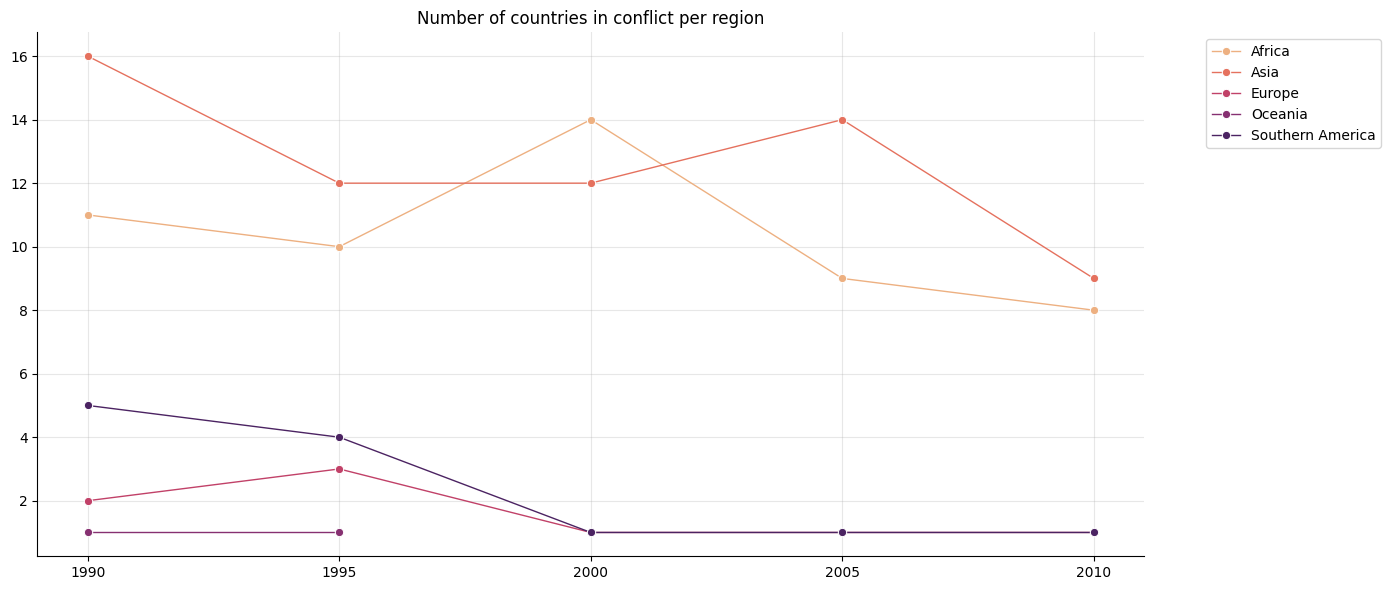

In [10]:
# Countries in conflict per year per region

conflict_countries = df[df["conflict_present"] == 1]
conflict_countries = conflict_countries.groupby(["year", "un_region"], as_index=False)["country"].nunique()

# regions unique
n = conflict_countries["un_region"].nunique()

# color for each region (from continuous to non continuous data)
colors = colormaps['flare'](np.linspace(0, 1, n))

plt.figure(figsize=(14,6))
sns.lineplot(
    data=conflict_countries,
    x="year",
    y="country",
    hue="un_region",
    marker="o",
    linewidth=1,
    markersize=6,
    palette=colors
)

# plot customize
sns.despine()
plt.title("Number of countries in conflict per region")
plt.xlabel("", fontsize = 10)
plt.ylabel("", fontsize = 10)
plt.grid(alpha=0.3)
plt.xticks(sorted(conflict_countries["year"].unique()))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize = 10)
plt.tight_layout()
plt.savefig("FigA.4.NbCountriesConflict_Year_Region_linechart.png", dpi=300)
plt.show()

In [12]:
conflict_years_per_country1 = (
    df.groupby(["country", "year","un_region"])["conflict_present"] # put all the variables in one row
    .mean()  # addition of all conflict_presence
    .reset_index(name="years_in_conflict")
) #could have done a wide format

conflict_years_per_country2 = (
    conflict_years_per_country1.groupby(["country","un_region"])["years_in_conflict"] # put all the variables in one row
    .sum()  # addition of all conflict_presence
    .reset_index(name="years_in_conflict")
)

country_summary = conflict_years_per_country2.describe()
conflict_years_per_country2

,country,un_region,years_in_conflict
0,Afghanistan,Asia,5.0
1,Albania,Europe,0.0
2,Algeria,Africa,4.0
3,Andorra,Europe,0.0
4,Angola,Africa,3.0
...,...,...,...
187,Venezuela (Bolivarian Republic Of),Southern America,0.0
188,Viet Nam,Asia,0.0
189,Yemen,Asia,0.0
190,Zambia,Africa,0.0


The majority of the countries did not experienced to be in conflict at the analysed years. 75% of them have experienced 1 mentioned year (which is different from a period) or not at all. Some countries could have encounter conflicts in between those years, which might not be reflected in the current dataset.

In [13]:
# Filter contries in conflict at least 1 mentioned year
countries_in_conflict = conflict_years_per_country2[conflict_years_per_country2["years_in_conflict"] > 0]

# Mean
mean_years_conflict = countries_in_conflict ["years_in_conflict"].mean()
#mean_years_conflict
## result: 2.63
#len(countries_in_conflict)
# result : 52

52 countries on 192 (27% a quarter) experienced conflict for 2 up to 3 reported years. 

In [14]:
# Analyze countries more often in conflict
conflict_3_of_5 = countries_in_conflict[
    (countries_in_conflict["years_in_conflict"] >= 3)]
conflict_3_of_5.describe()

,years_in_conflict
count,24.000000
mean,4.125000
std,0.797414
min,3.000000
25%,3.750000
50%,4.000000
75%,5.000000
max,5.000000


In [16]:
# A list of countries with =>3 years of conflict
country_conflict_list = conflict_3_of_5.country.unique()

# Selct the initial data
df_selected = df[df["country"].isin(country_conflict_list)]

# did not find it alone! it applies a transofrmation for each row (i.e. religion in each country) to calculate the value of the religion (pop) 
# divided by the sum of relig_pop for this year in this country
df_selected["prop_relig"] = df_selected.groupby(["country","year"])["relig_pop"].transform(lambda x: x / x.sum())

df_selected
df_selected.to_csv("df_selected.csv")

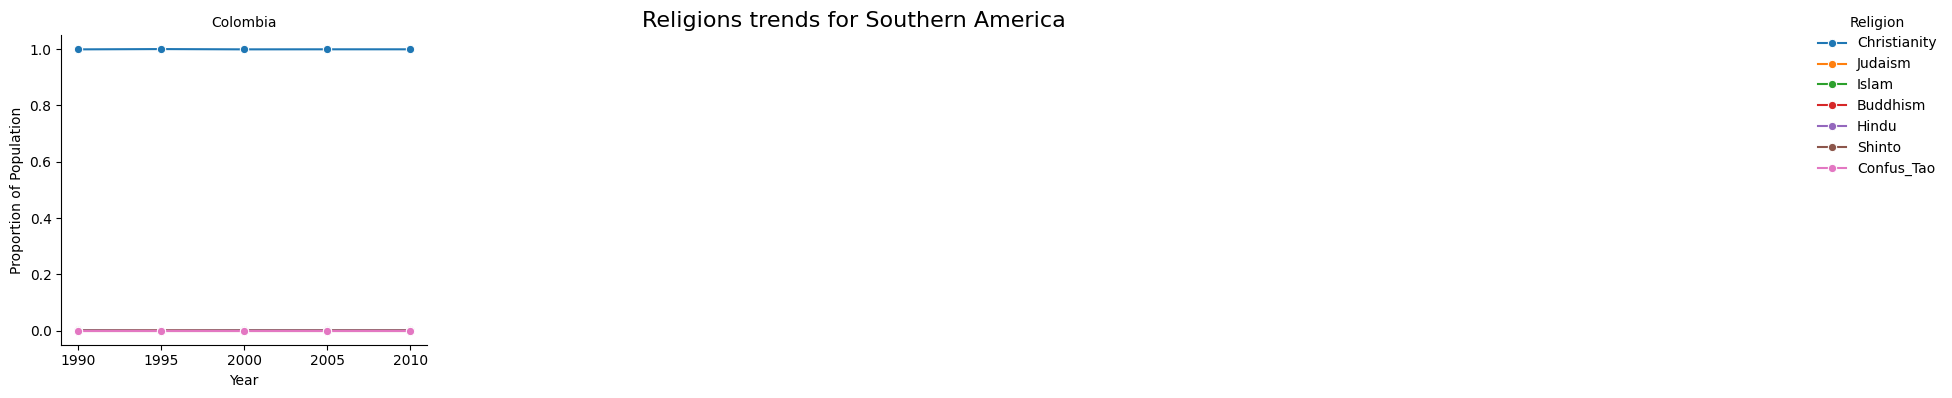

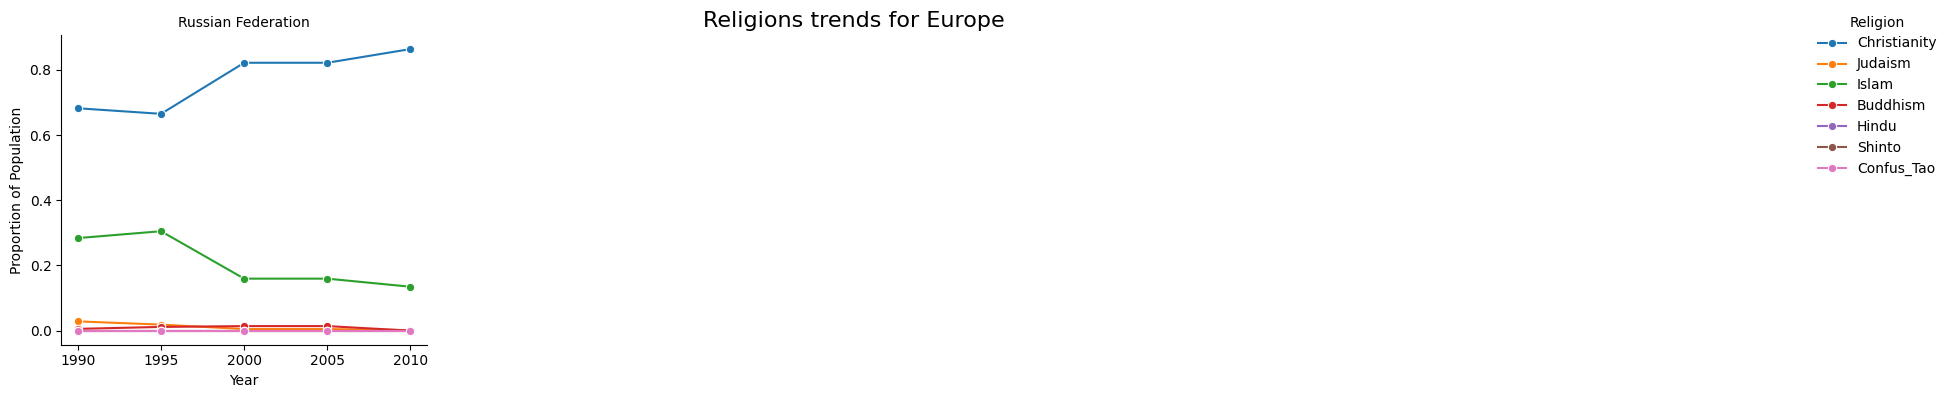

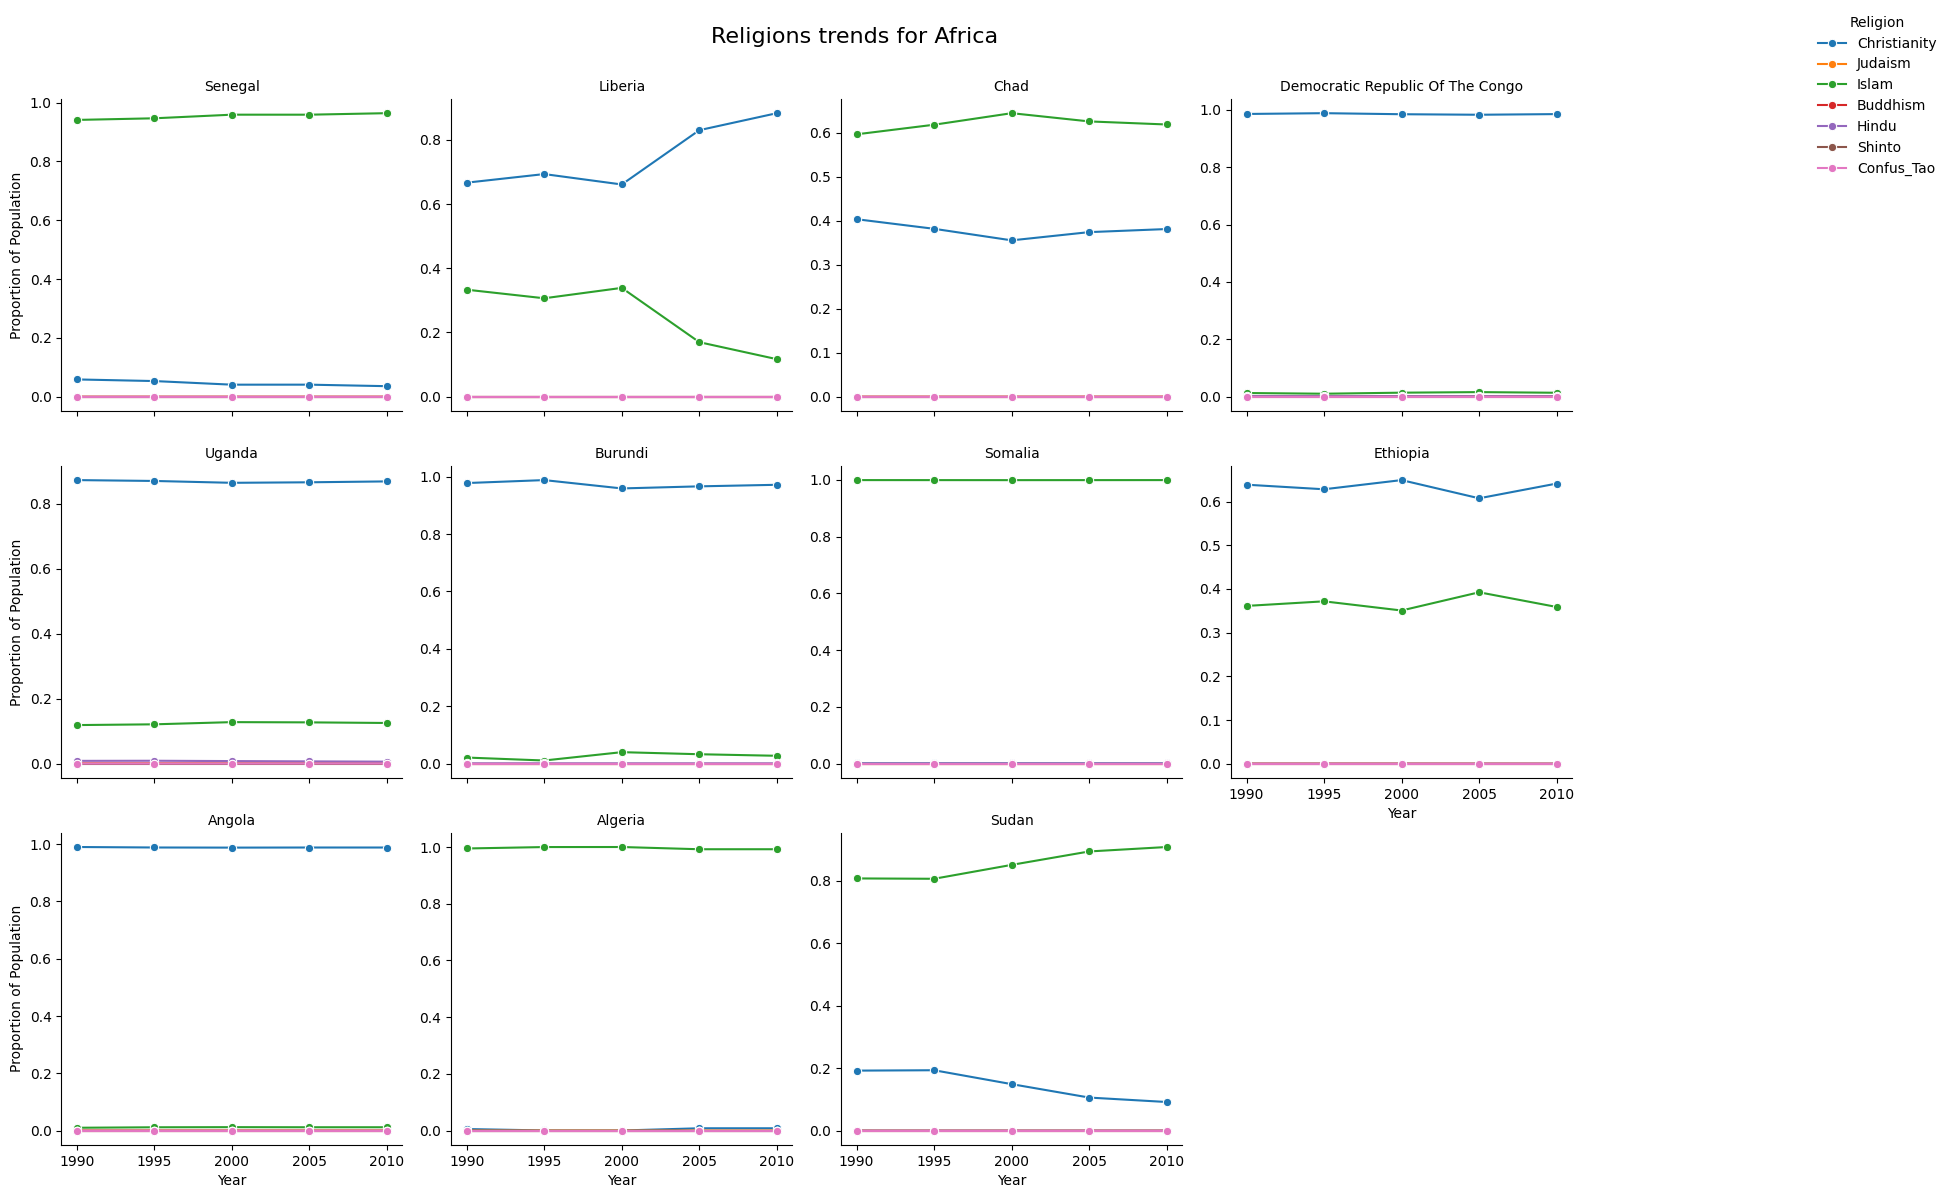

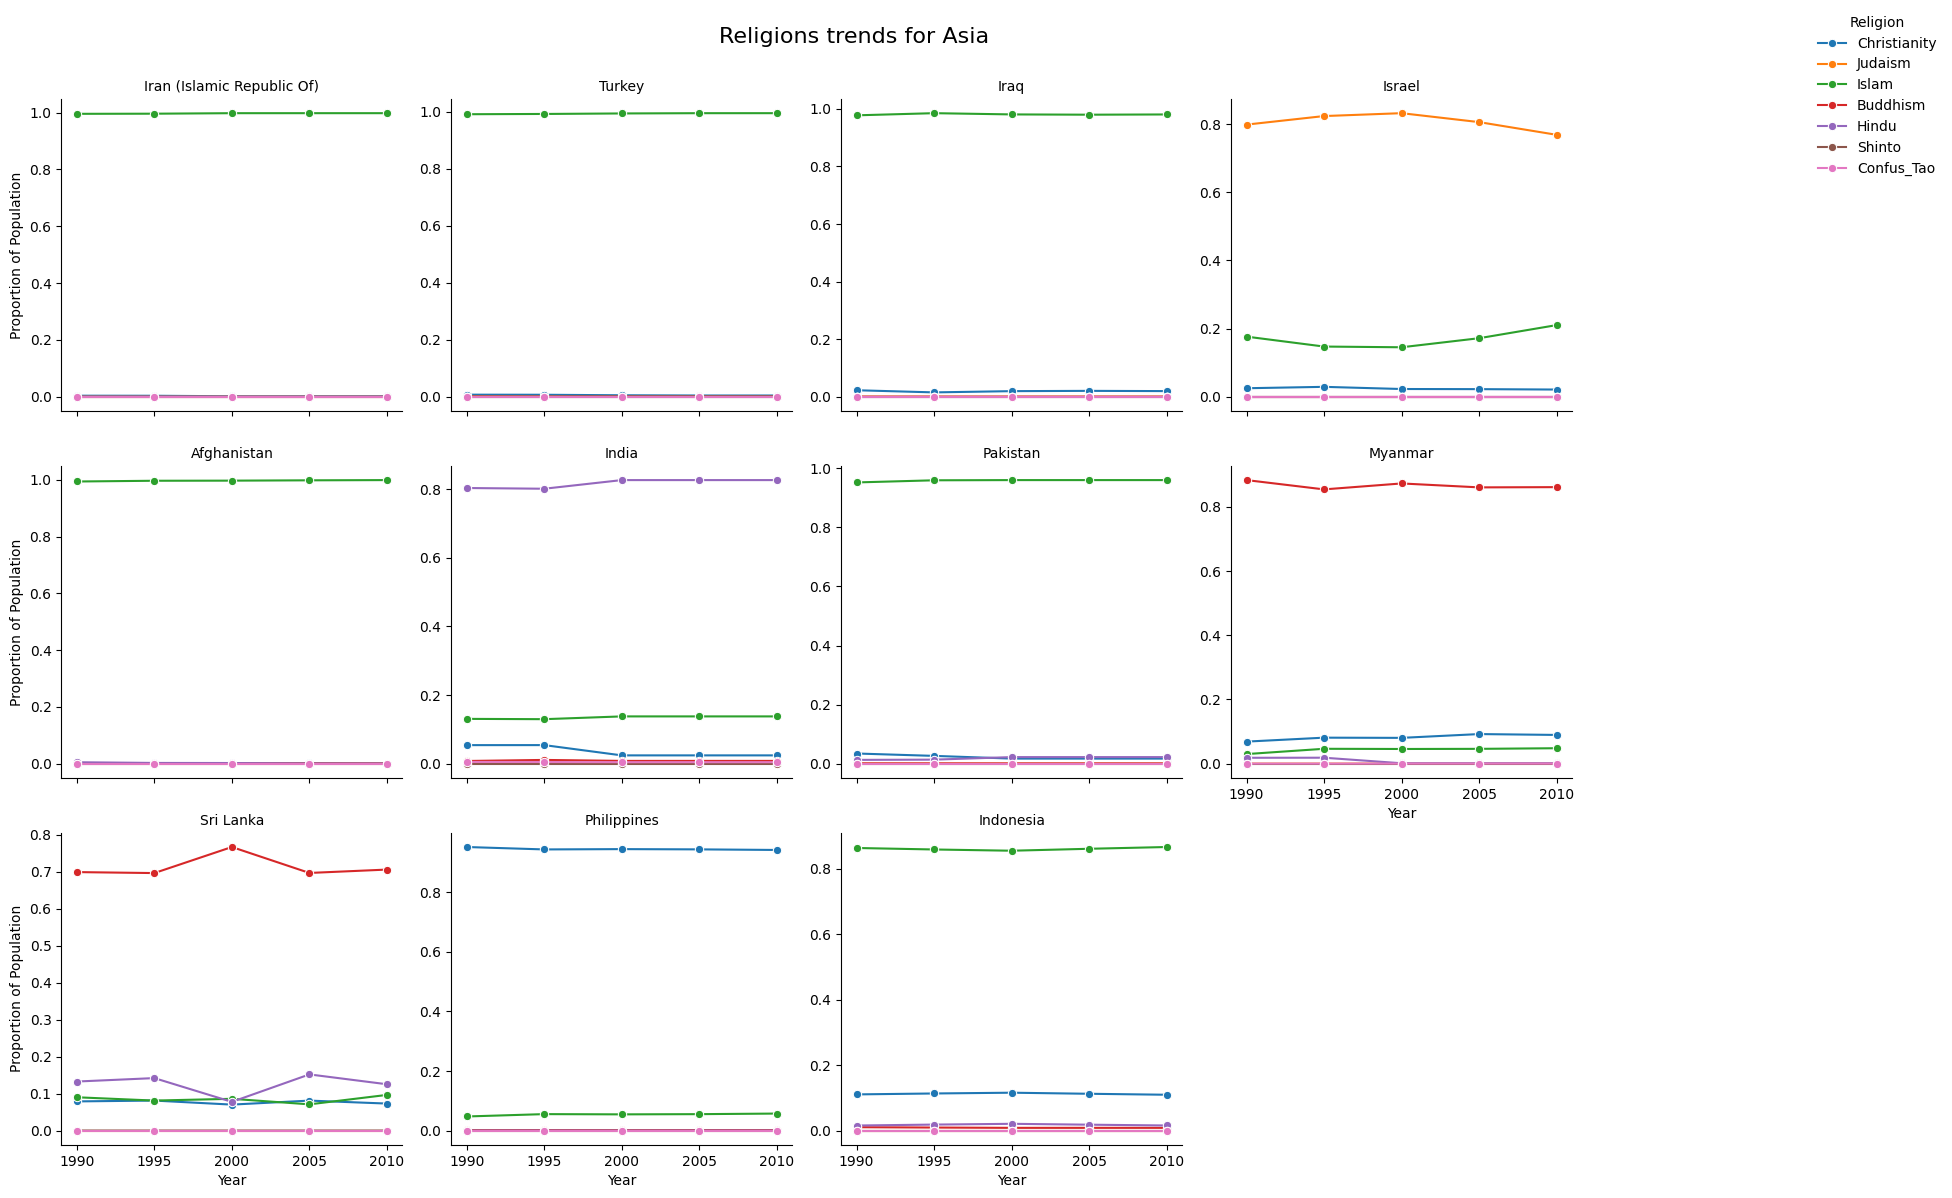

In [25]:
# Plotting facet grid region and countries
for region in df_selected["un_region"].unique():
    df_region = df_selected[df_selected["un_region"] == region]
    num_countries = len(country_conflict_list)
    if num_countries == 0:
        continue  # next

    cols = 4
    rows = (num_countries + cols - 1) // cols # (n + k - 1) // k // means division integer it is a trick
    
    g = sns.FacetGrid(
        df_region,
        col="country",
        col_wrap=cols,
        height=4,
        sharey=False
    )
    
    g.map_dataframe(
        sns.lineplot,
        x="year",
        y="prop_relig",
        hue="religion",
        marker="o"
    )
    
    g.set_axis_labels("Year", "Proportion of Population")
    g.set_titles(col_template="{col_name}")
    g.add_legend(title="Religion", bbox_to_anchor=(1.05,1), loc="upper left")
    plt.subplots_adjust(top=0.92)
    g.fig.suptitle(f"Religions trends for {region}", fontsize=16)
    plt.savefig(f"FigA.5.ReligiousTrends_country_region_facegrid_{region}.png")
    plt.show()

In [30]:
# Filter contries out of conflicts
countries_no_conflict = conflict_years_per_country2[conflict_years_per_country2["years_in_conflict"] == 0]

# Mean
mean_years_no_conflict = countries_no_conflict ["years_in_conflict"].mean()
#mean_years_no_conflict
## result: 0
#len(mean_years_no_conflict)
# result : 140

In [33]:
# A list of countries with = 0 years of conflict
no_conflict_list = countries_no_conflict .country.unique()

# Selct the initial data
df_selected_0 = df[df["country"].isin(no_conflict_list)]

# did not find it alone! it applies a transofrmation for each row (i.e. religion in each country) to calculate the value of the religion (pop) 
# divided by the sum of relig_pop for this year in this country
df_selected_0["prop_relig"] = df_selected_0.groupby(["country","year"])["relig_pop"].transform(lambda x: x / x.sum())

df_selected_0


,year,country,gdp,un_region,hdi,conflict_present,religion,relig_pop,prop_relig
0,1990,United States,5.963144e+12,Northern America,0.875,0.0,Christianity,214425162,0.956001
1,1995,United States,7.639749e+12,Northern America,0.000,0.0,Christianity,215593975,0.955724
2,2000,United States,1.025095e+13,Northern America,0.894,0.0,Christianity,219818305,0.952692
3,2005,United States,1.303920e+13,Northern America,0.000,0.0,Christianity,226464805,0.944264
4,2010,United States,1.504896e+13,Northern America,0.916,0.0,Christianity,233111307,0.942517
...,...,...,...,...,...,...,...,...,...
6449,1990,Samoa,1.257663e+08,Oceania,0.672,0.0,Confus_Tao,0,0.000000
6450,1995,Samoa,2.248657e+08,Oceania,0.000,0.0,Confus_Tao,0,0.000000
6451,2000,Samoa,2.588561e+08,Oceania,0.672,0.0,Confus_Tao,0,0.000000
6452,2005,Samoa,4.768018e+08,Oceania,0.000,0.0,Confus_Tao,0,0.000000


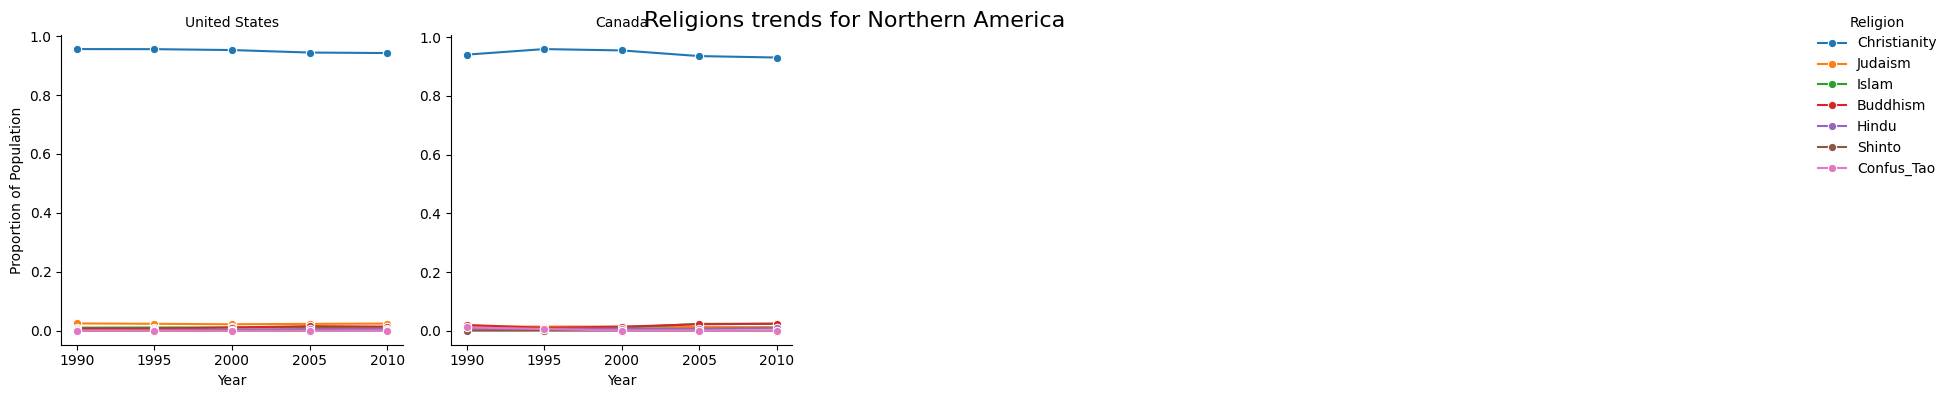

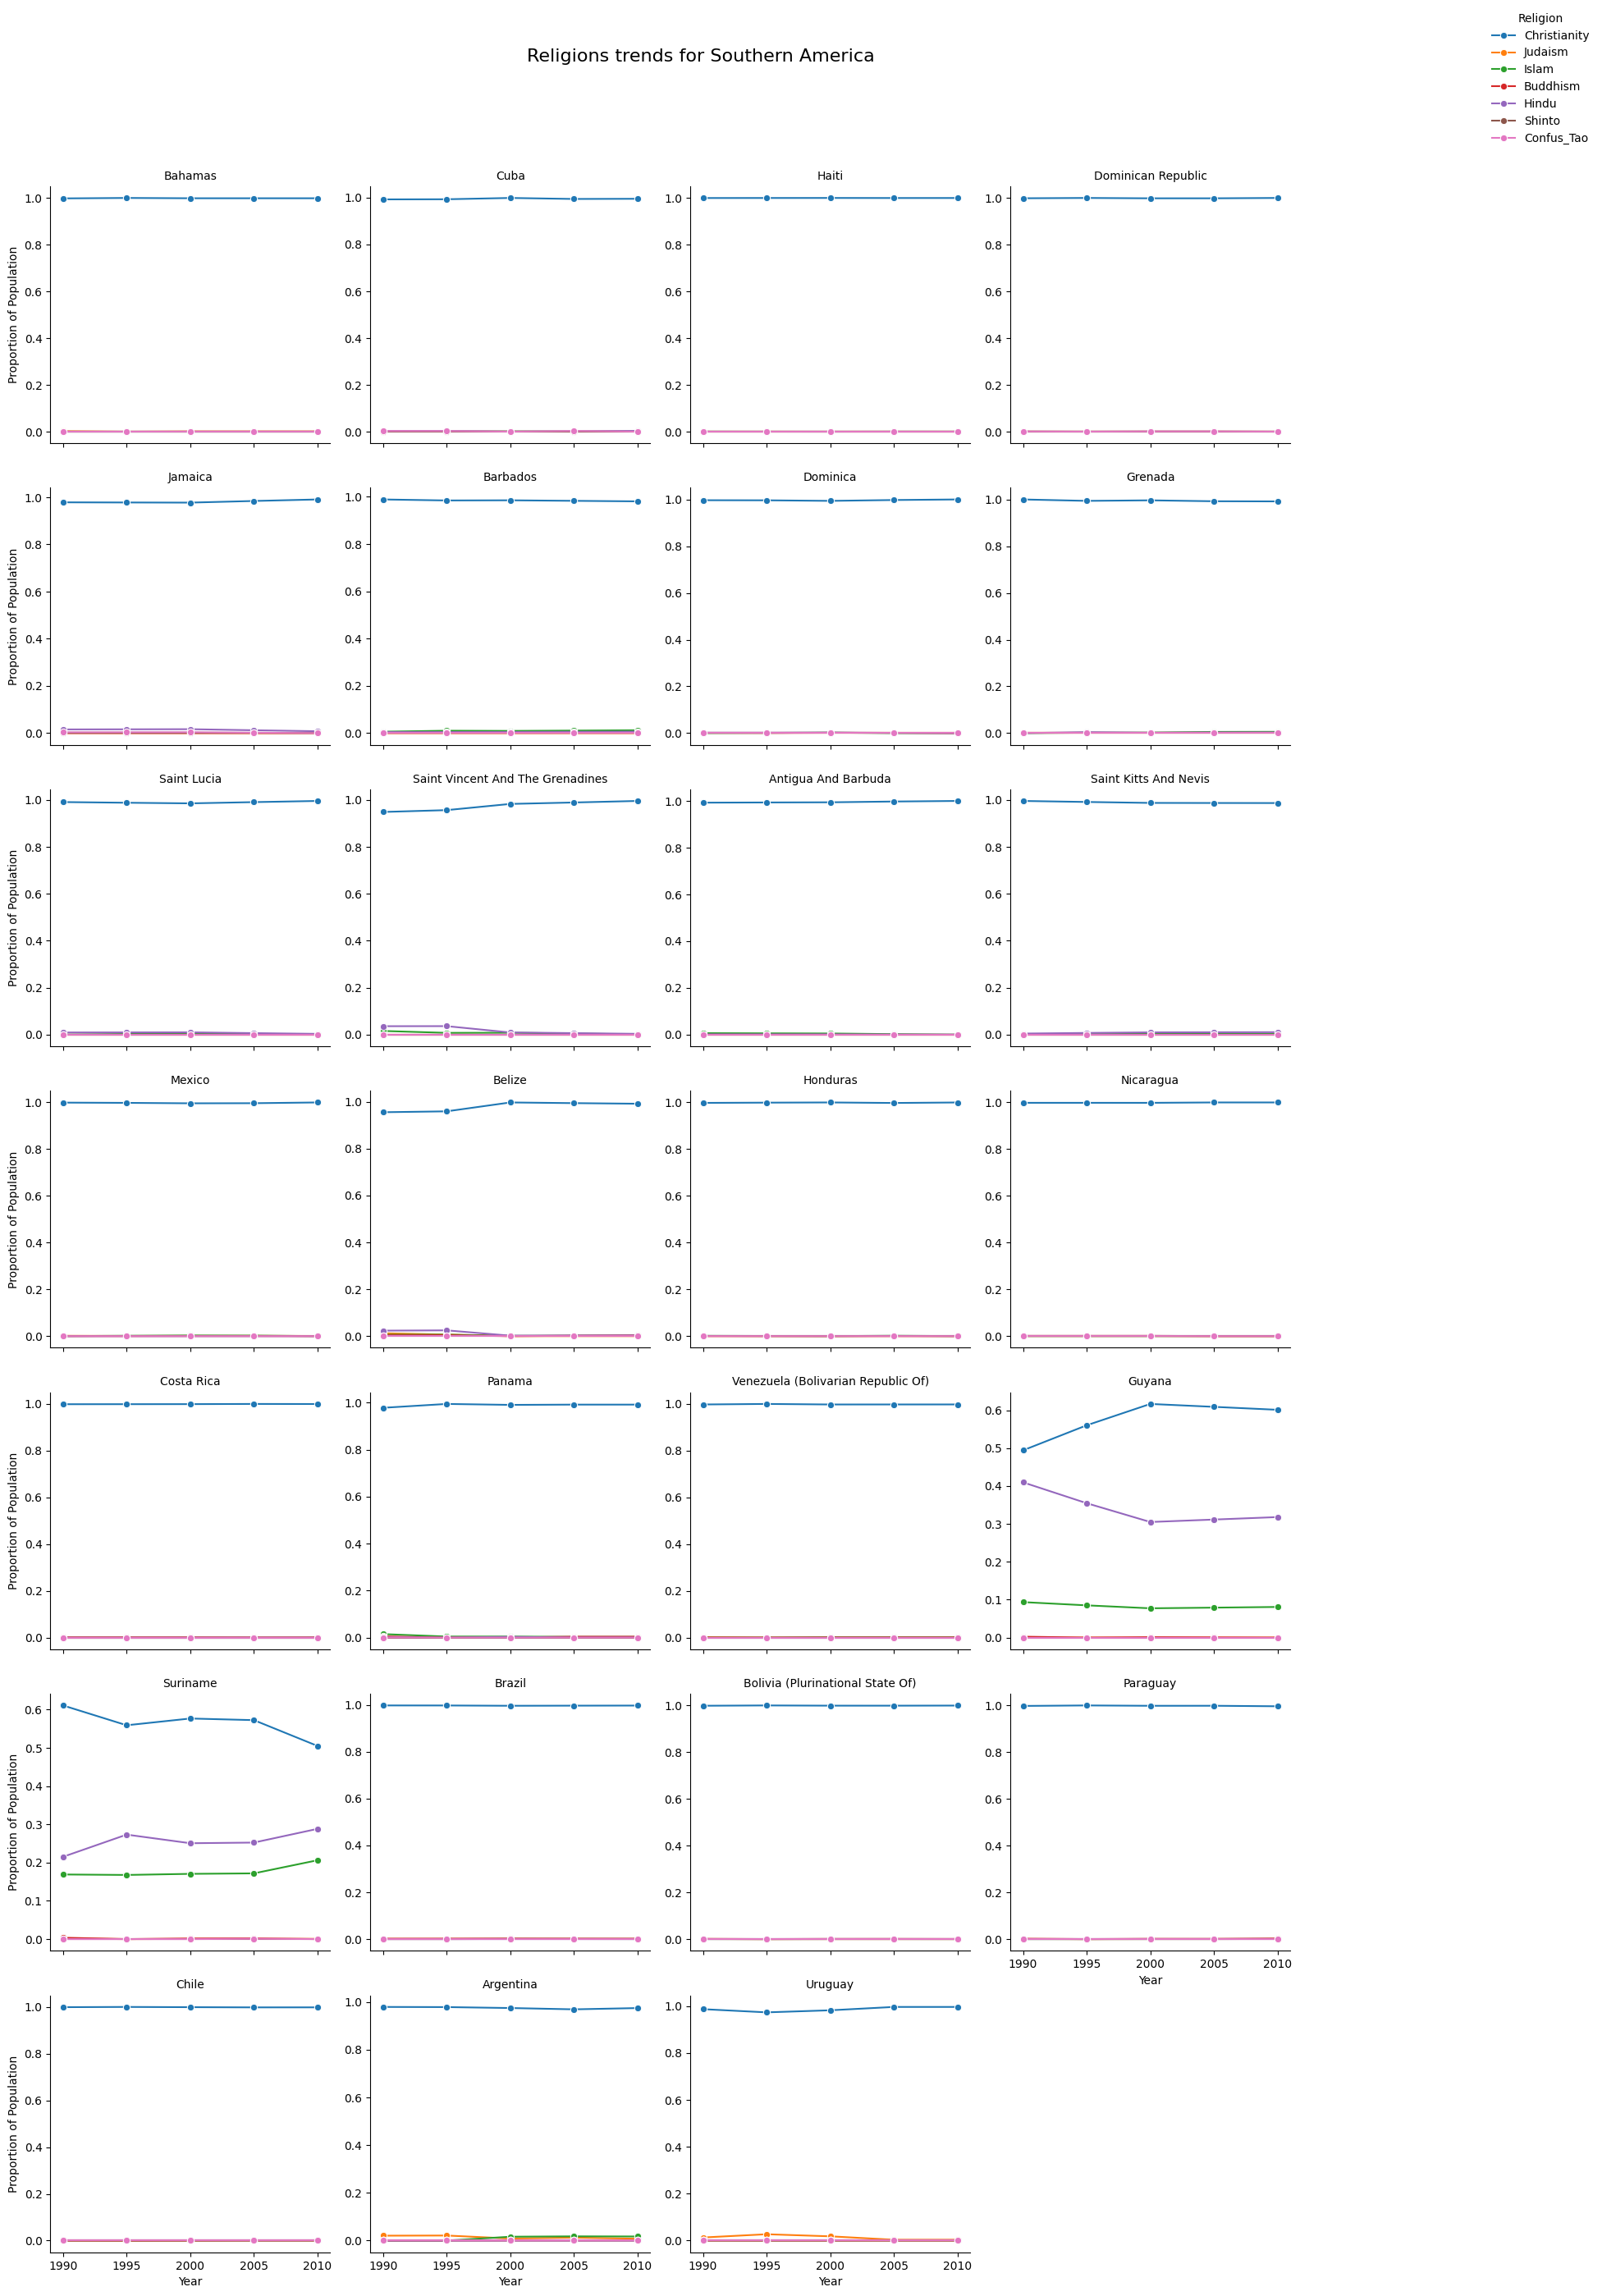

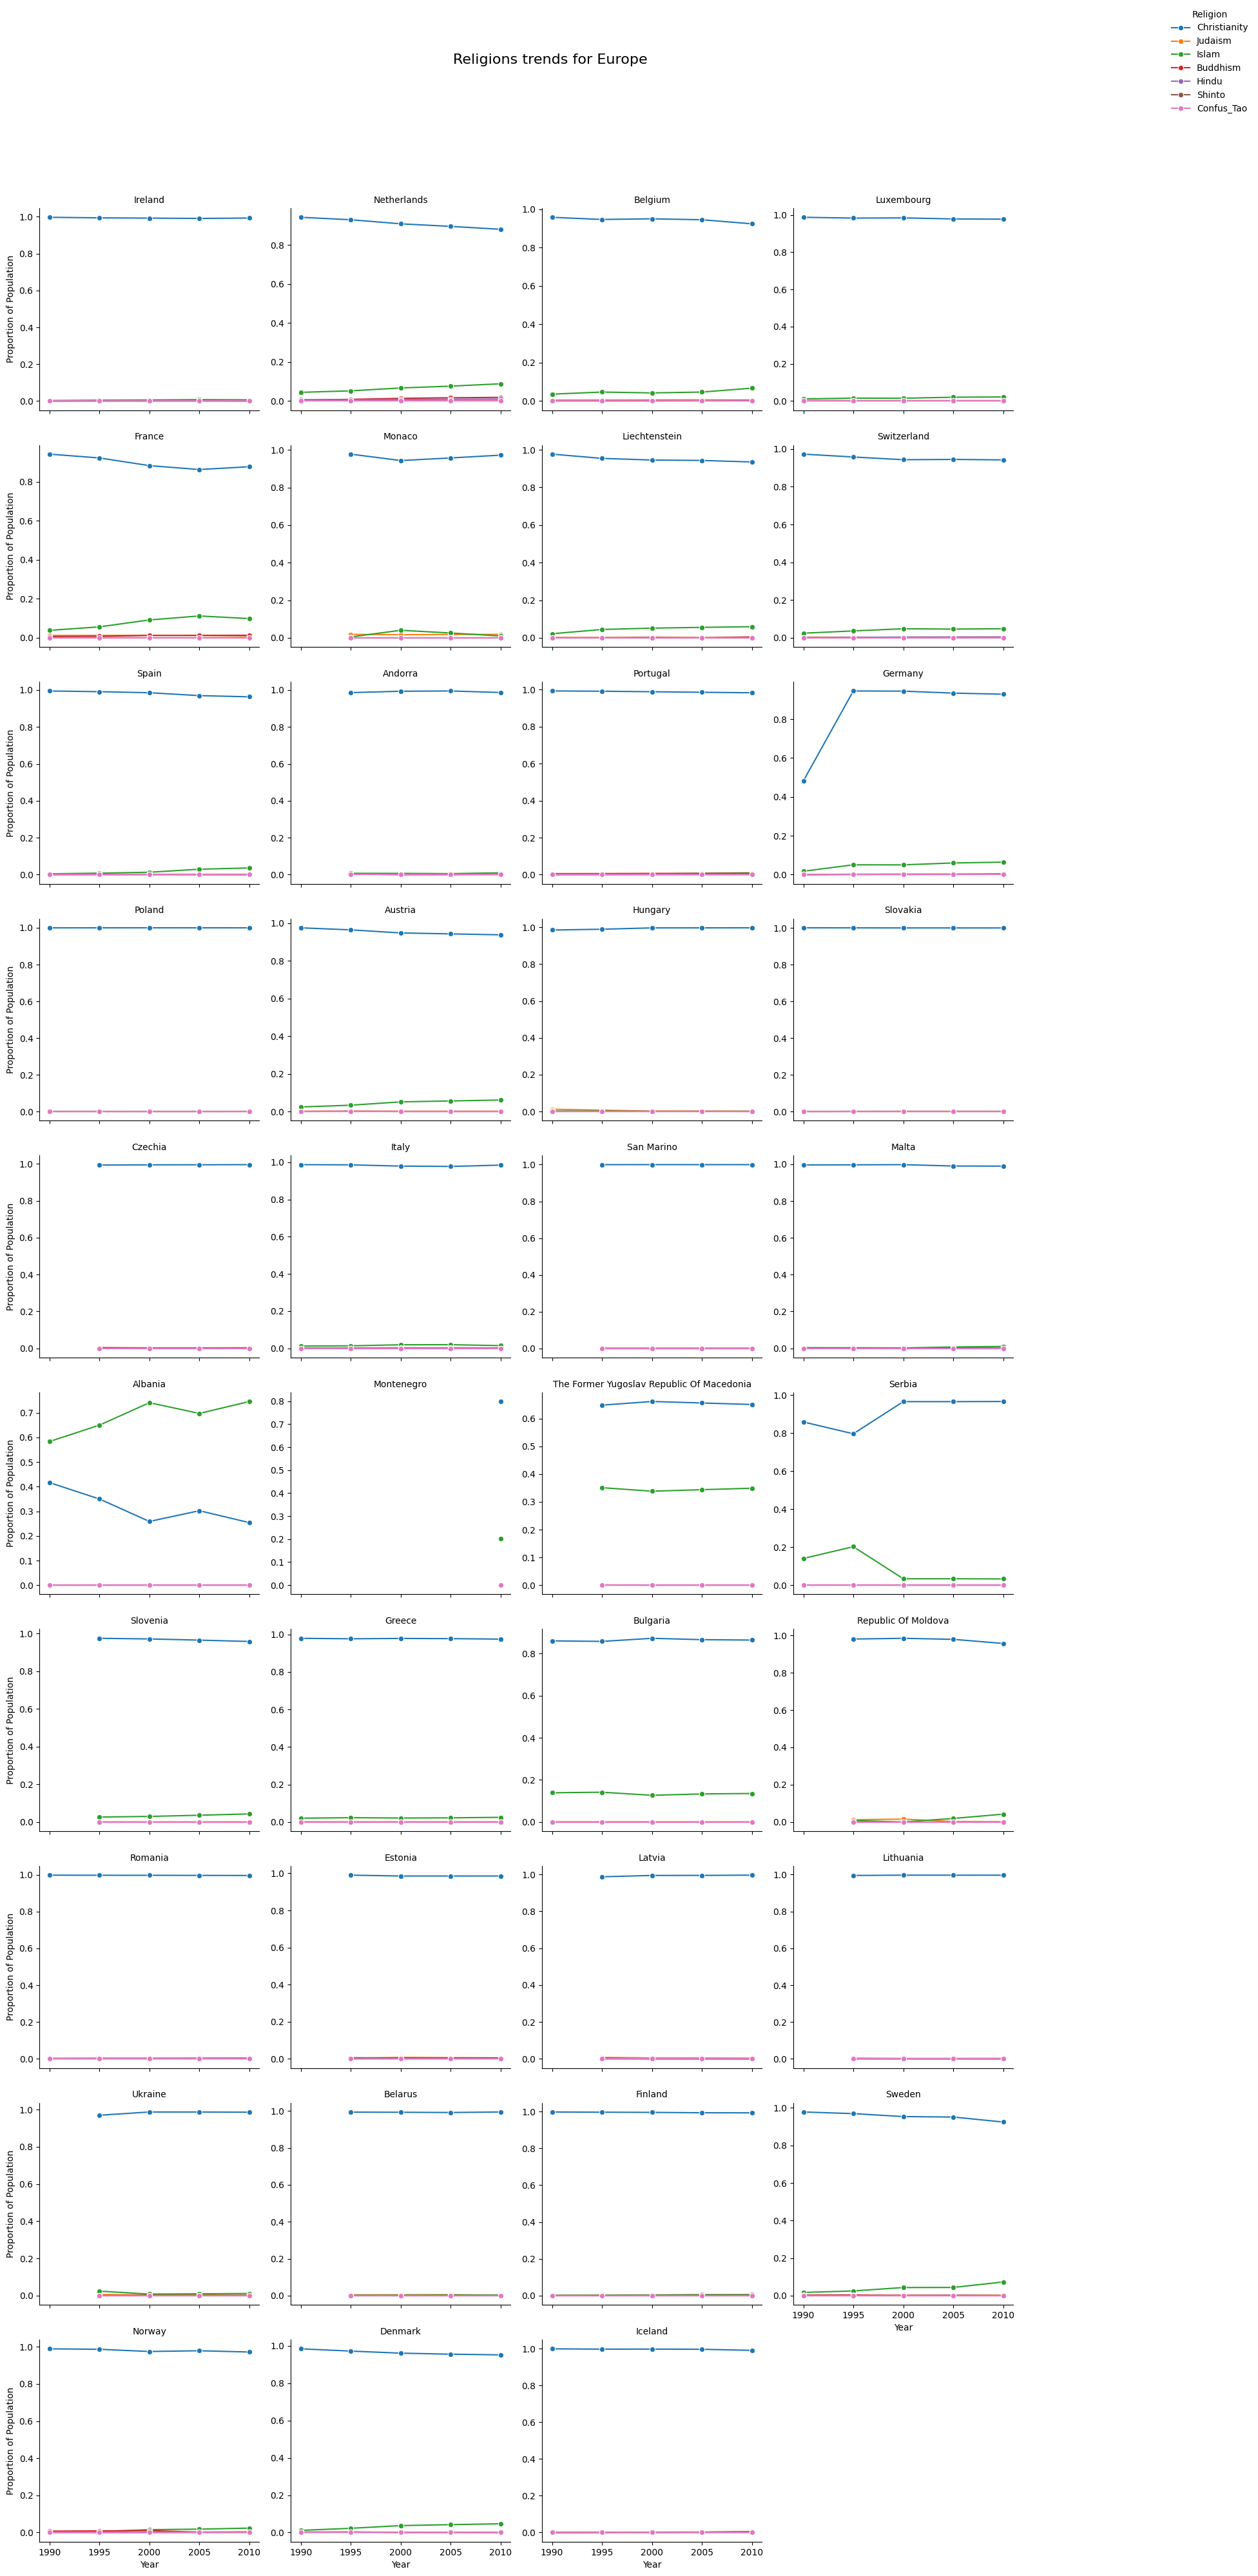

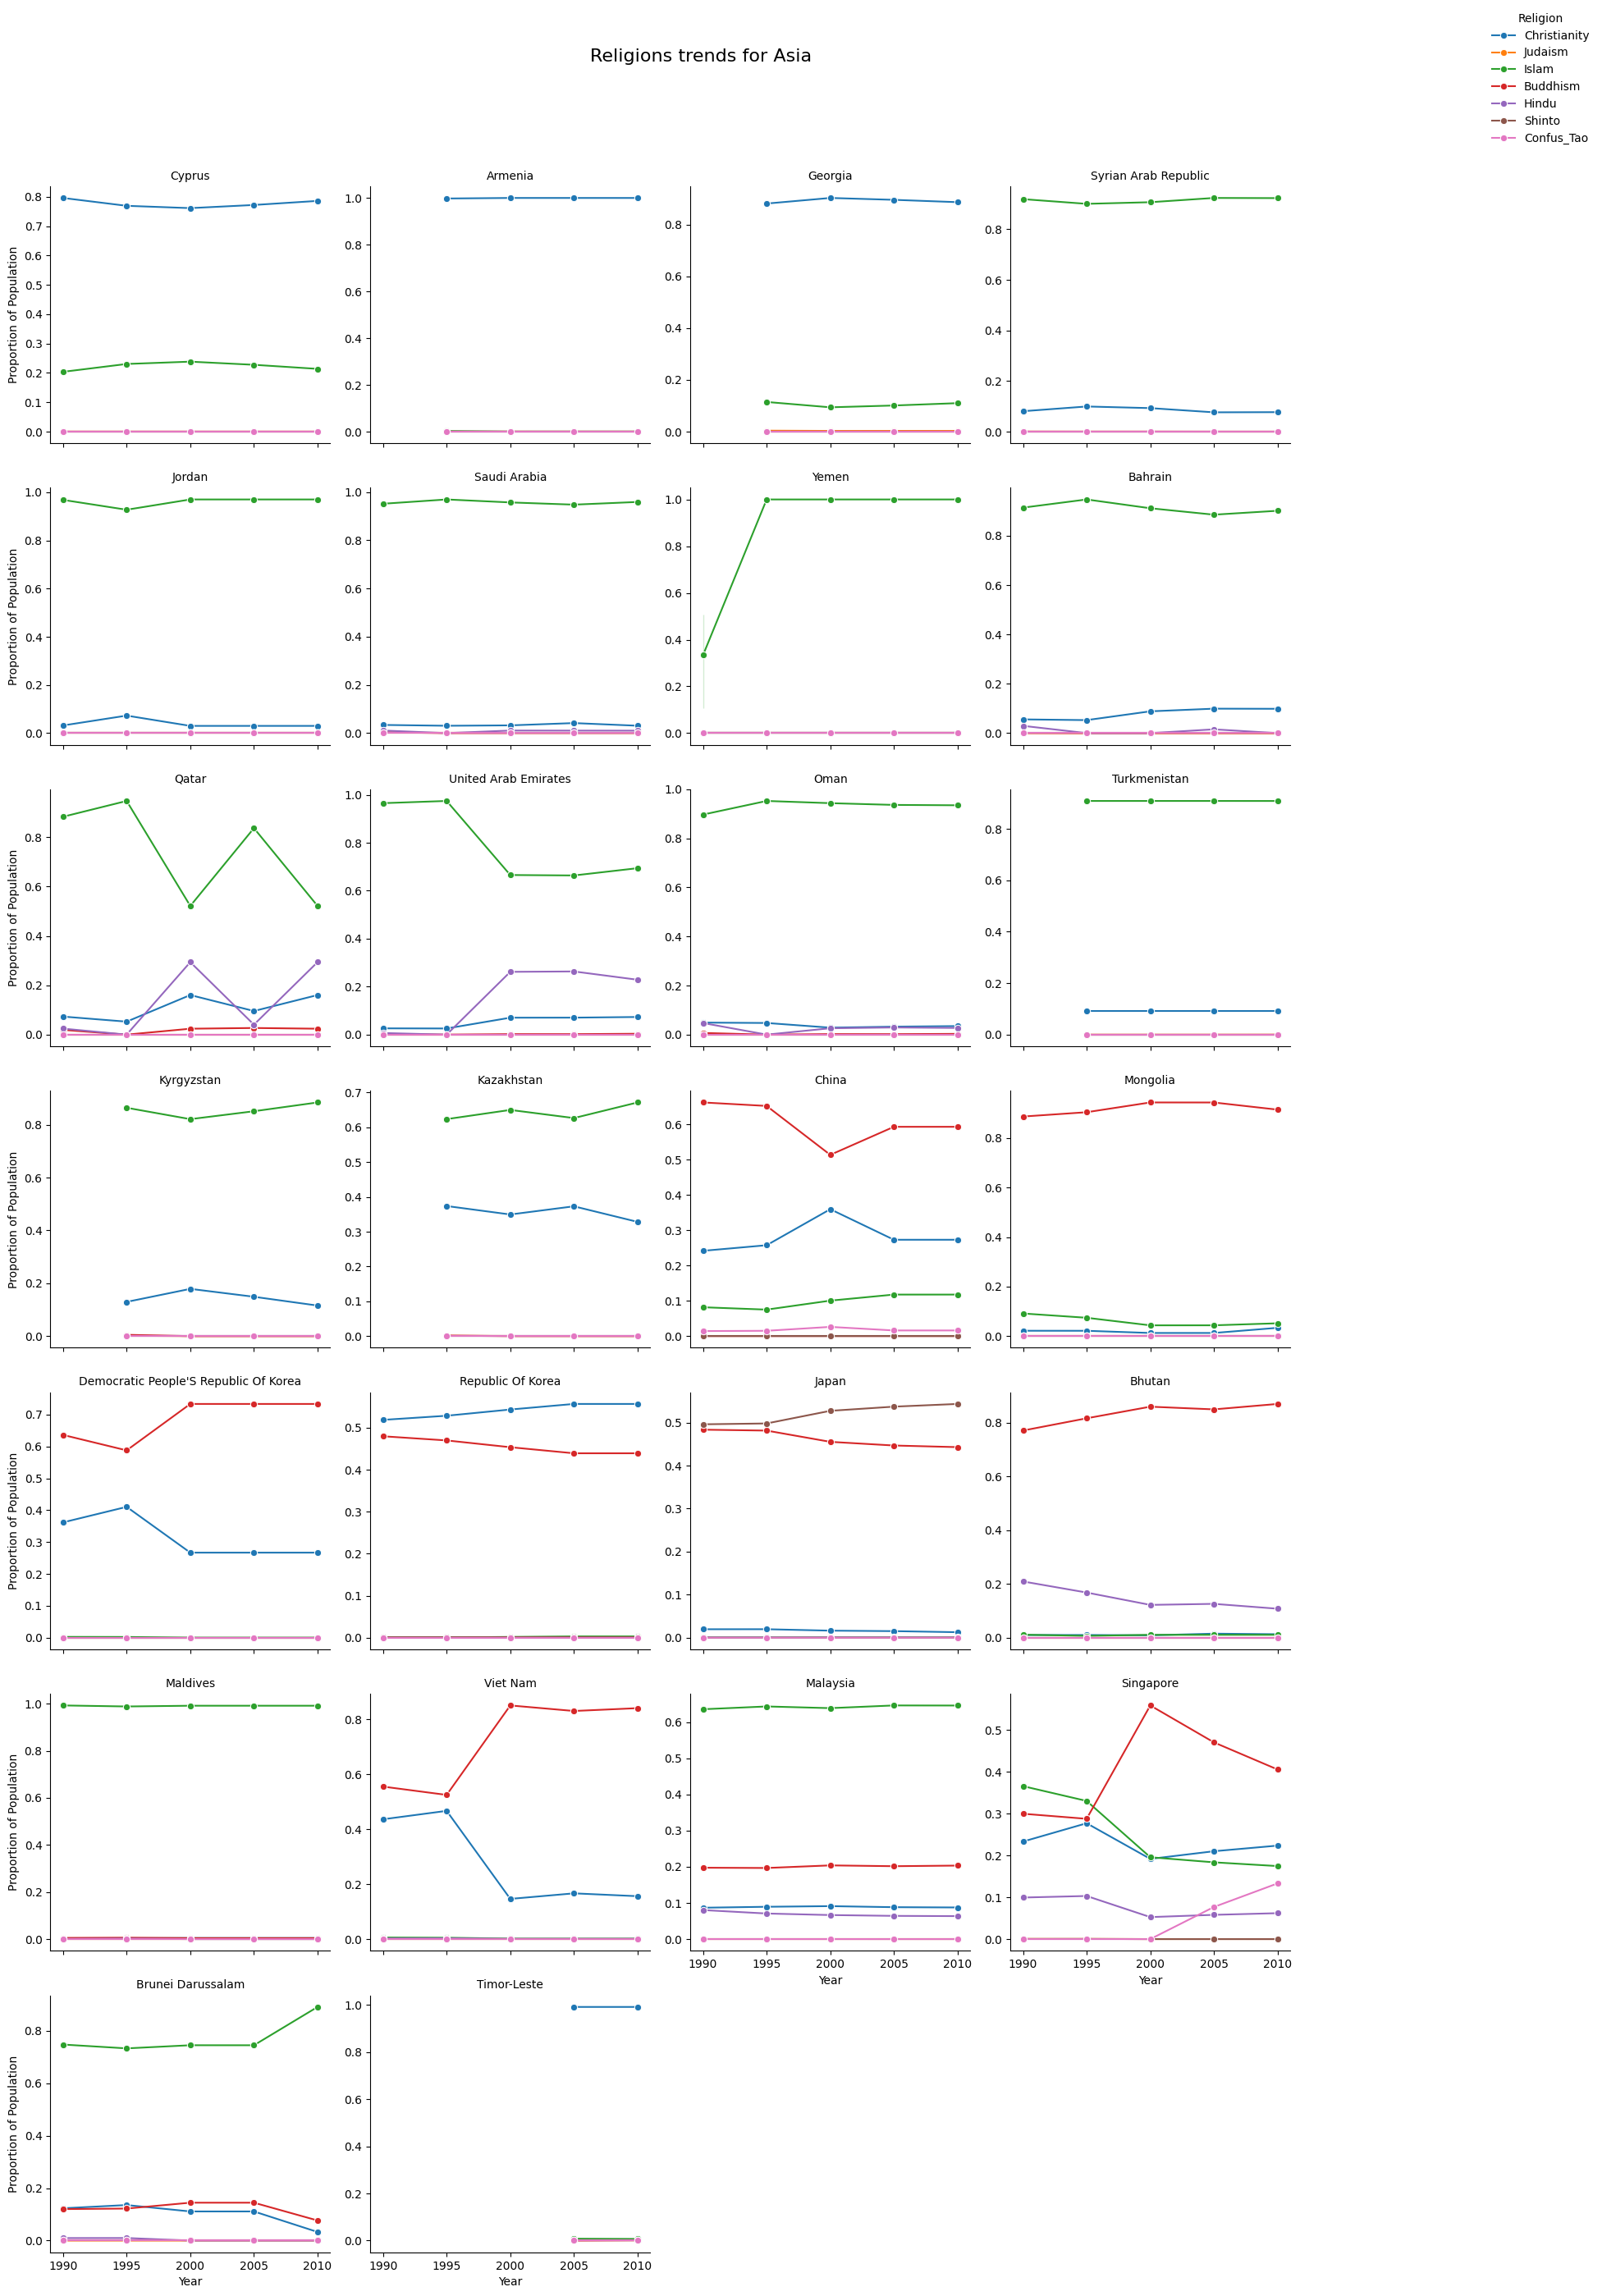

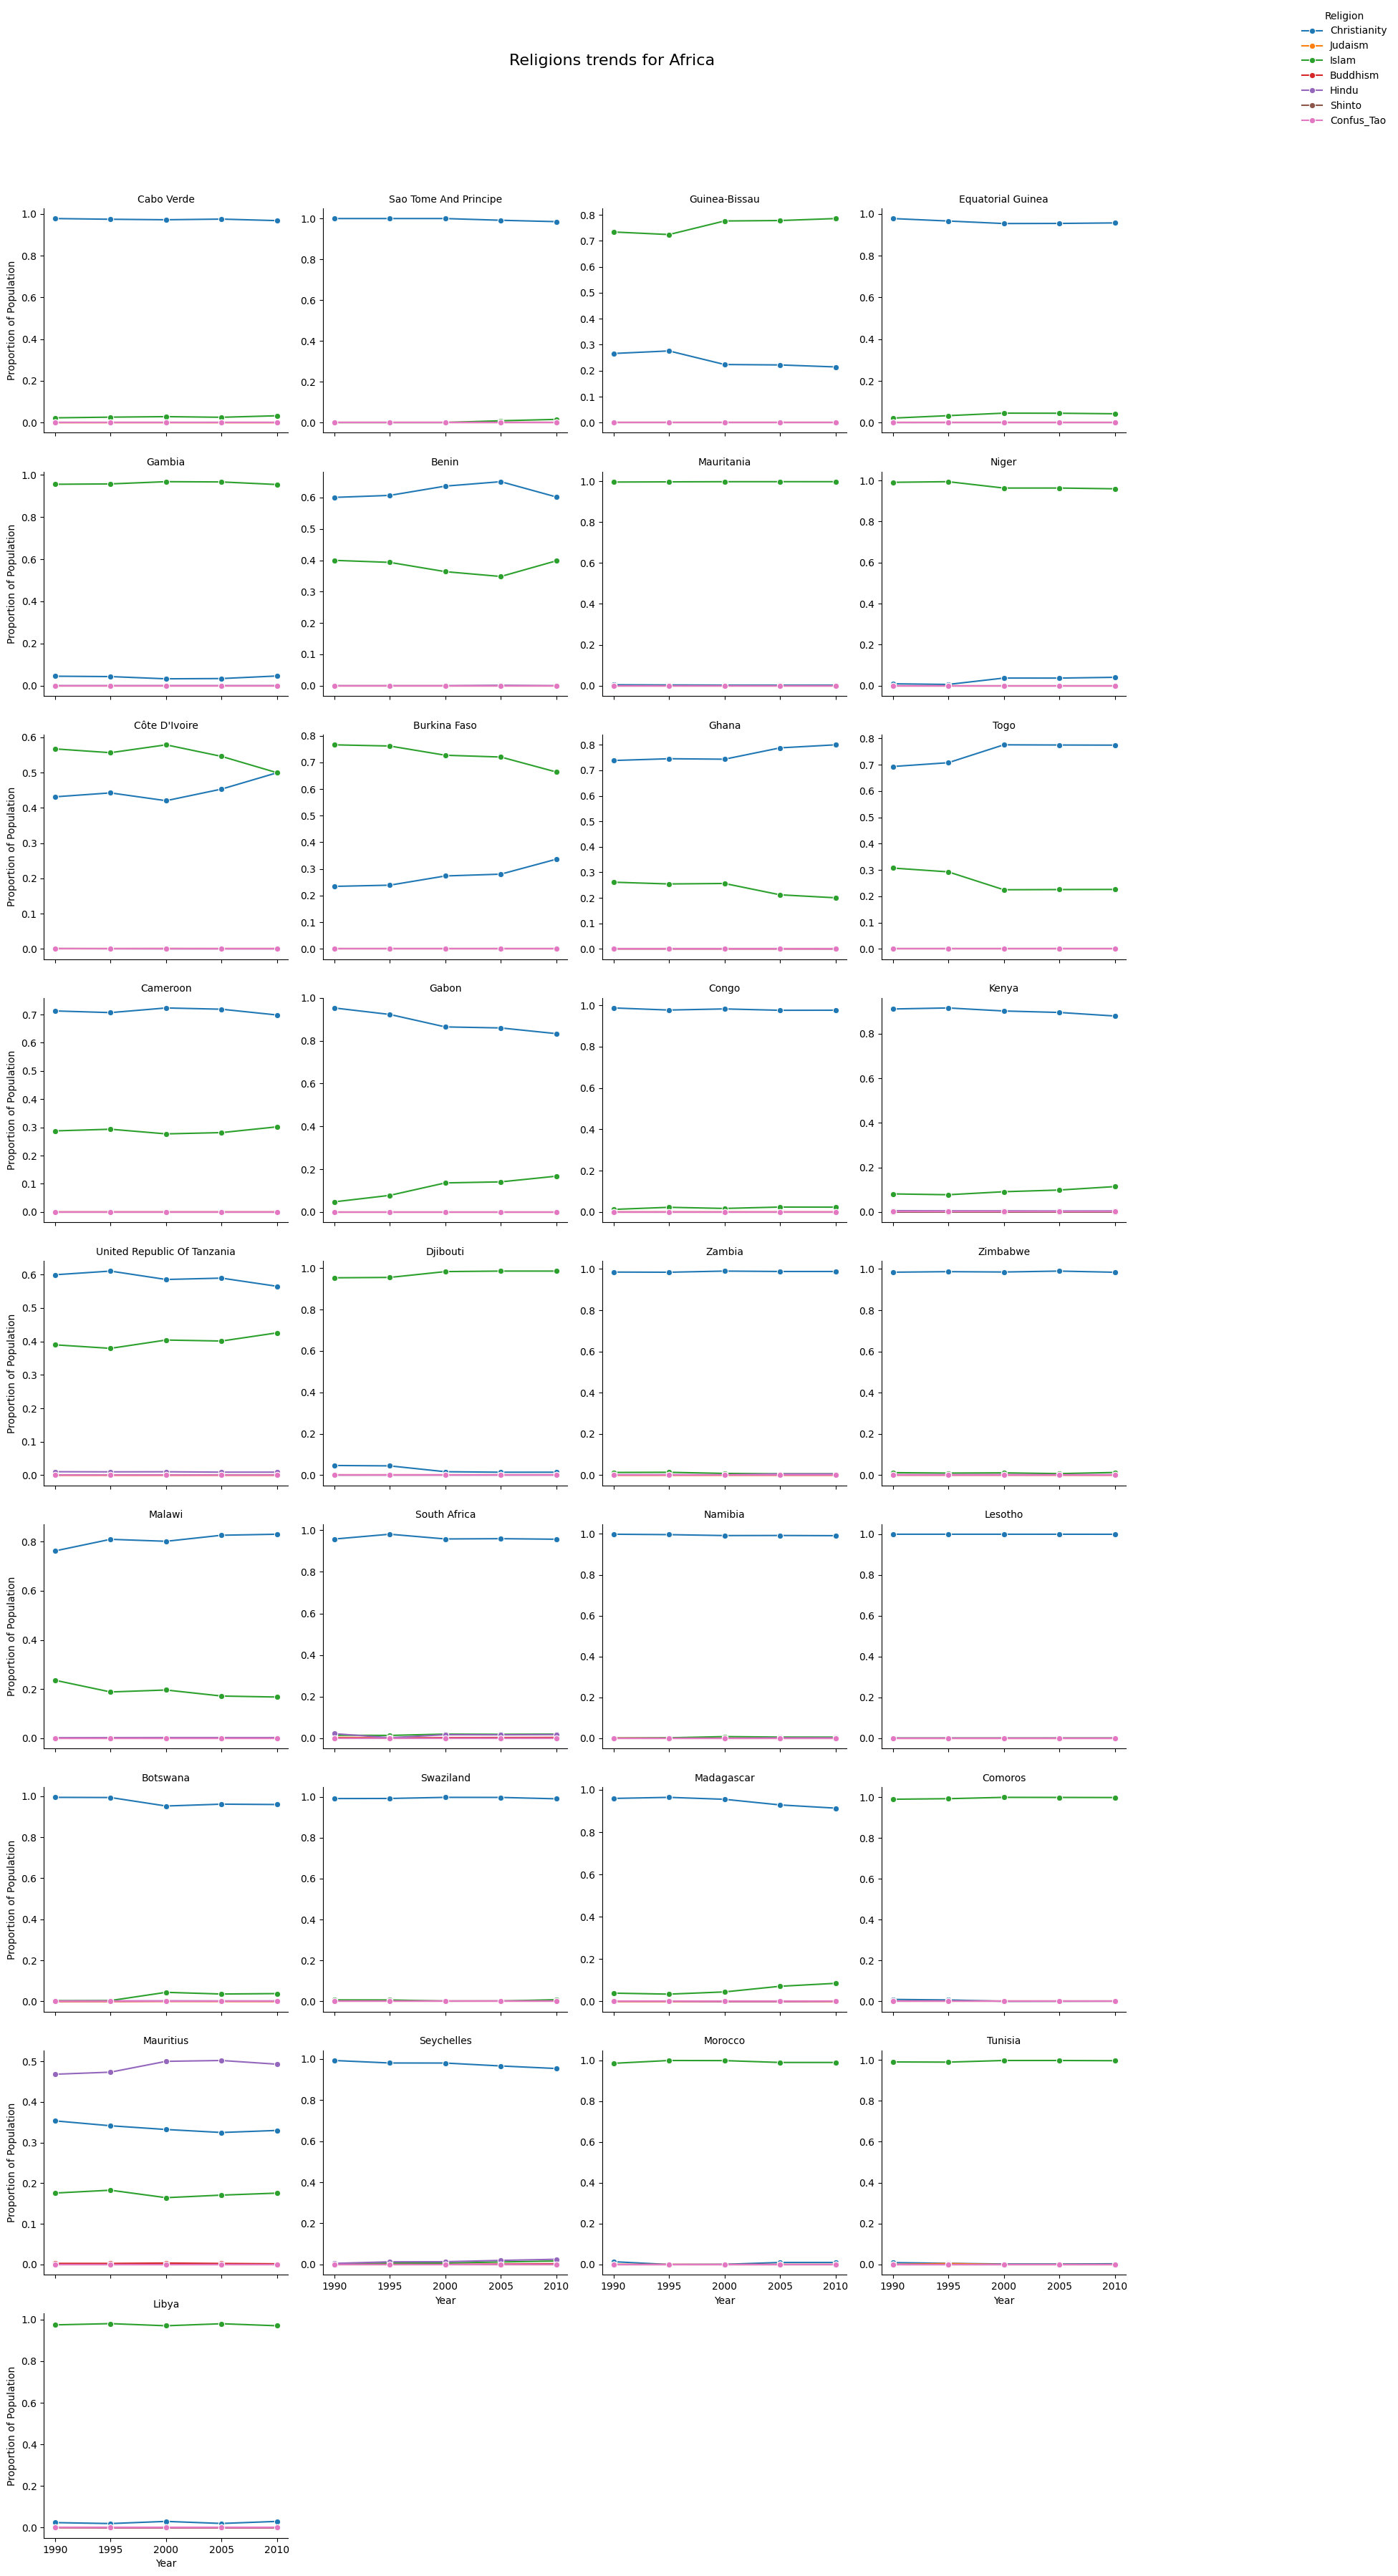

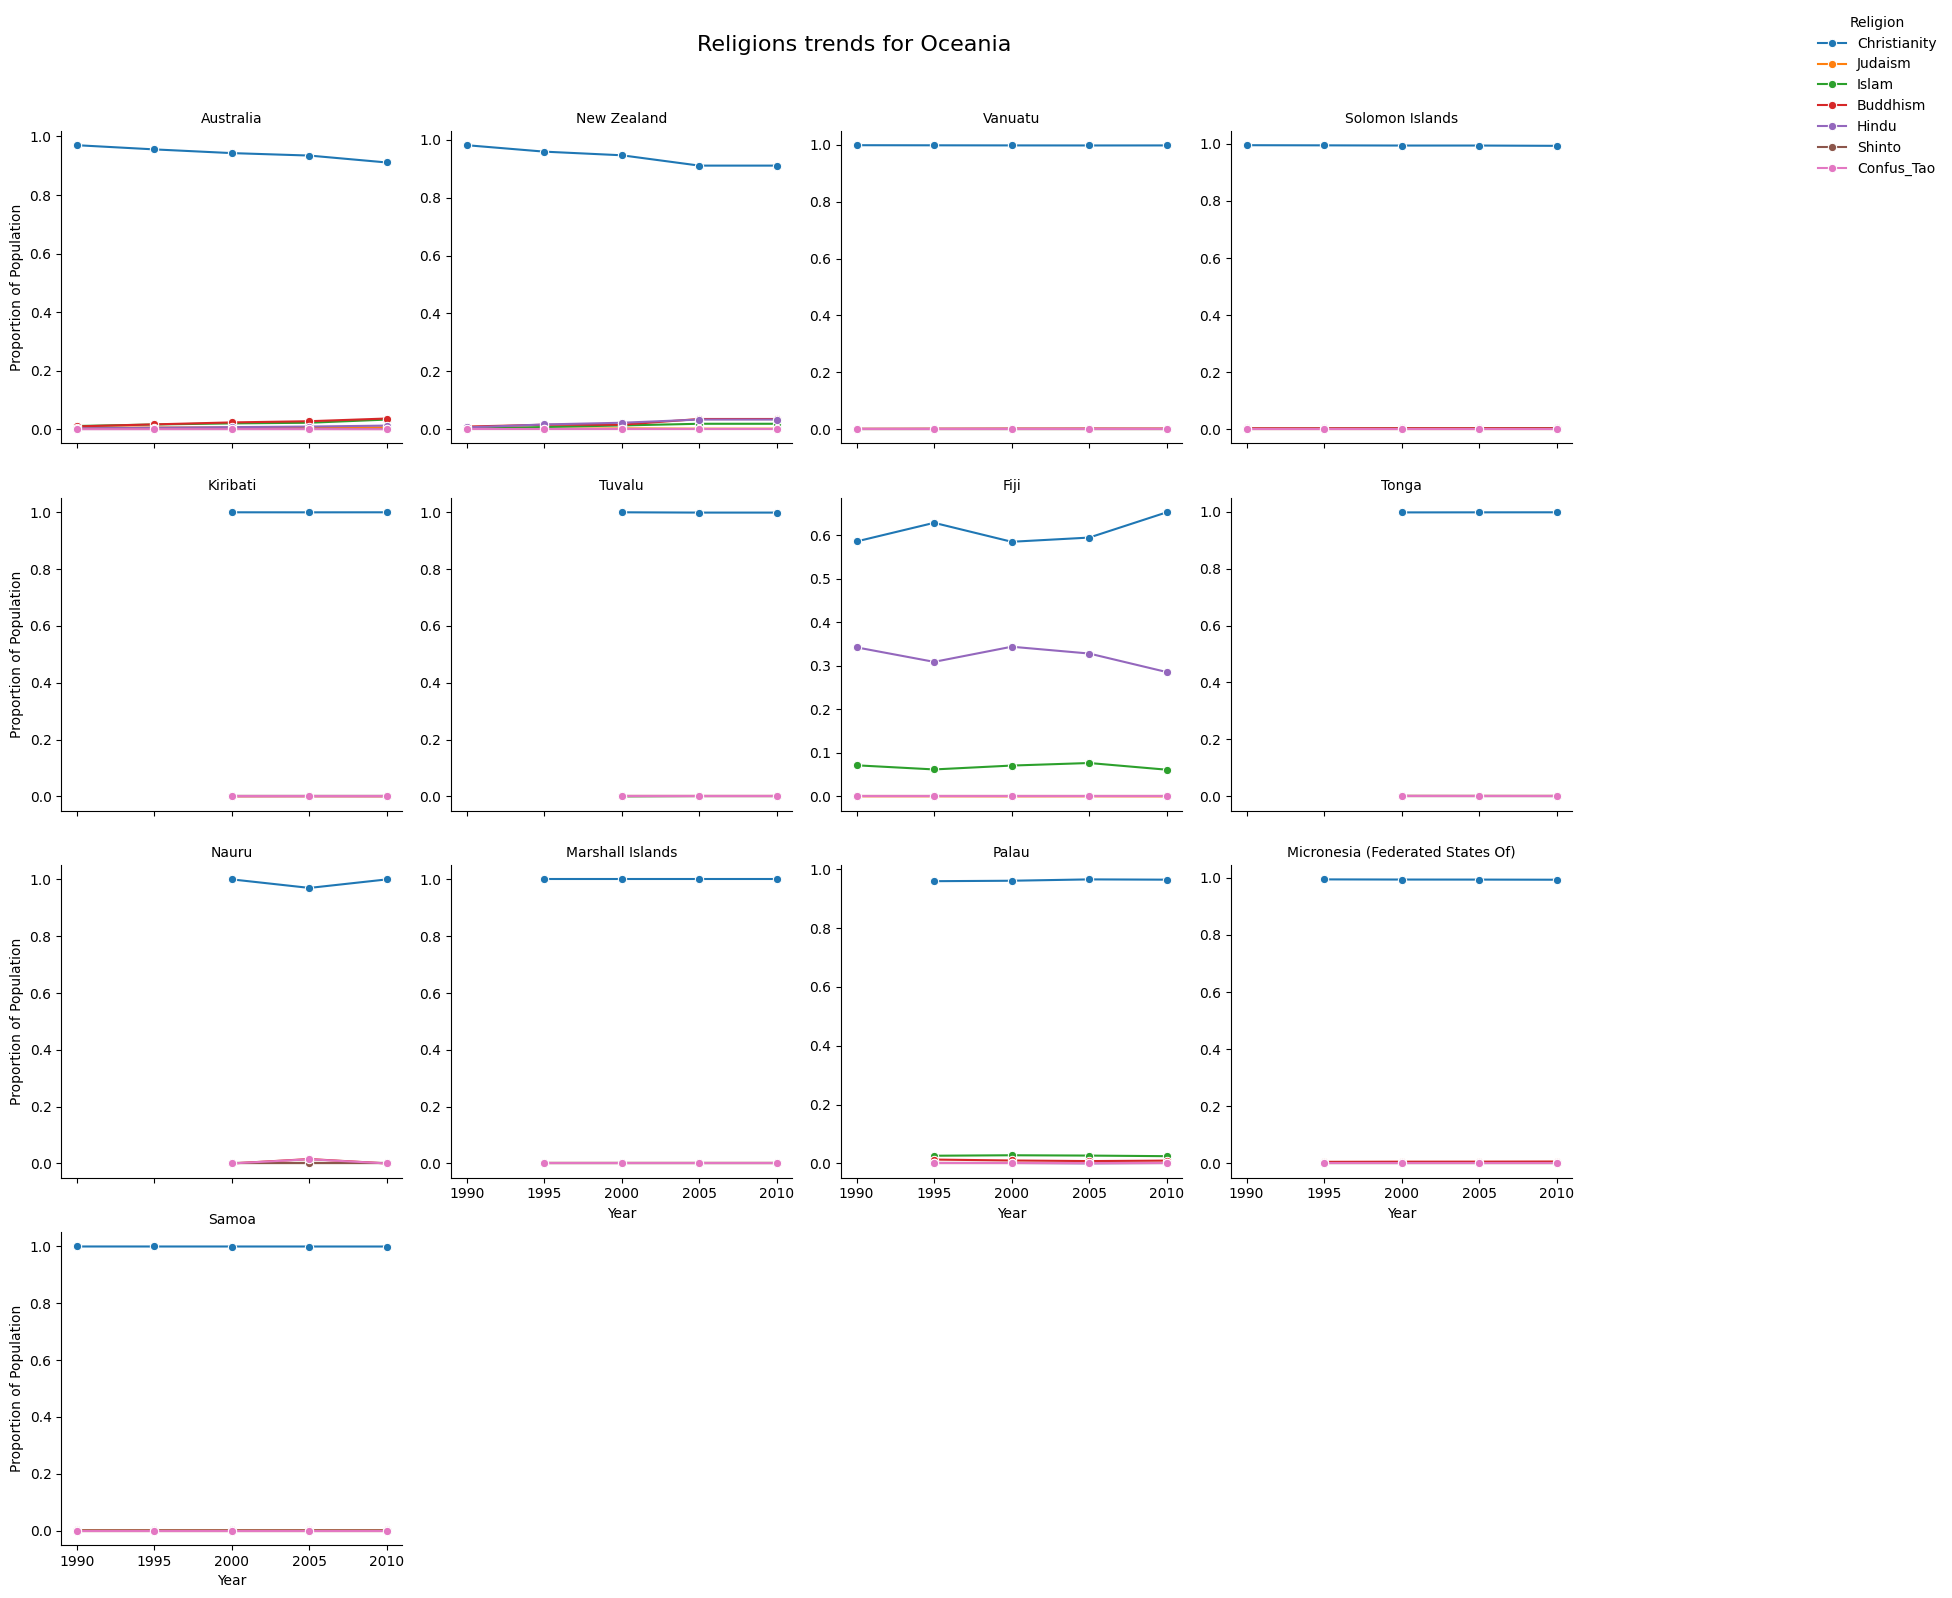

In [36]:
# Plotting facet grid region and countries
for region in df_selected_0["un_region"].unique():
    df_region = df_selected_0[df_selected_0["un_region"] == region]
    num_countries = len(no_conflict_list)
    
    if num_countries == 0:
        continue  # next

    cols = 4
    rows = (num_countries + cols - 1) // cols # (n + k - 1) // k // means division integer it is a trick
    
    g = sns.FacetGrid(
        df_region,
        col="country",
        col_wrap=cols,
        height=4,
        sharey=False
    )
    
    g.map_dataframe(
        sns.lineplot,
        x="year",
        y="prop_relig",
        hue="religion",
        marker="o"
    )
    
    g.set_axis_labels("Year", "Proportion of Population")
    g.set_titles(col_template="{col_name}")
    g.add_legend(title="Religion", bbox_to_anchor=(1.05,1), loc="upper left")
    plt.subplots_adjust(top=0.92)
    g.fig.suptitle(f"Religions trends for {region}", fontsize=16)
    plt.savefig(f"FigA.6.ReligiousTrends_country_region_facegrid_{region}.png")
    plt.show()

In [37]:
df_selected

,year,country,gdp,un_region,hdi,conflict_present,religion,relig_pop,prop_relig
115,1990,Colombia,4.784409e+10,Southern America,0.614,1.0,Christianity,30980000,0.998773
116,1995,Colombia,9.250728e+10,Southern America,0.000,1.0,Christianity,33756907,0.999807
117,2000,Colombia,9.987507e+10,Southern America,0.672,1.0,Christianity,39996945,0.998809
118,2005,Colombia,1.456005e+11,Southern America,0.000,1.0,Christianity,41606496,0.998987
119,2010,Colombia,2.864985e+11,Southern America,0.732,1.0,Christianity,44910647,0.998987
...,...,...,...,...,...,...,...,...,...
6388,1990,Indonesia,1.061407e+11,Asia,0.526,1.0,Confus_Tao,0,0.000000
6389,1995,Indonesia,2.021320e+11,Asia,0.000,0.0,Confus_Tao,0,0.000000
6390,2000,Indonesia,1.650210e+11,Asia,0.597,1.0,Confus_Tao,0,0.000000
6391,2005,Indonesia,2.858686e+11,Asia,0.000,1.0,Confus_Tao,0,0.000000
